# 07 · Functional maps & shape distances

**SpectralBrain tutorial series — notebook 7 of 10.** (Previous: point clouds & tracts.)

We can describe a shape; now we *relate* shapes. Three ideas: **functional maps**
transfer information between two surfaces; **intrinsic distances** measure
separation *within* one surface along its geometry; **point-set distances**
measure how far apart two surfaces sit *in space*. The contrast between intrinsic
(pose-free) and extrinsic (pose-dependent) closes the loop on why spectral methods
are special.

### Learning objectives
1. Compute a functional map between two hippocampi and read its structure.
2. Compute and render biharmonic, commute-time, and diffusion distances.
3. Use Chamfer and Hausdorff distances and see their pose dependence.


## 1. Functional maps: corresponding shapes through their spectra

Classical correspondence asks "which point on shape B matches point $x$ on shape
A?" Ovsjanikov et al. (2012) reframed it: instead of mapping points, map
**functions**. A functional map $C$ is a small matrix that converts the
eigenbasis coefficients of a function on A into those on B:

$$\hat{g}_B \;=\; C\,\hat{g}_A .$$

For (near-)isometric shapes, $C$ is nearly **diagonal**, because matching
eigenfunctions carry matching information. The further from isometric, the more
$C$ spreads off-diagonal. We compute $C$ between two left hippocampi using their
HKS fields as soft constraints, and look at its structure.

[06/09/26 02:09:05] INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 02:09:06] INFO     Laplacian (cotangent): N=8192, nnz=56578

functional map C: (30, 30)


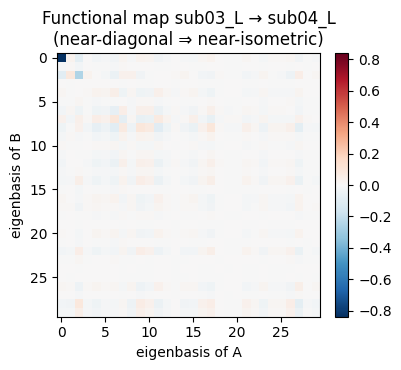

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain as sb
from _tutorial_utils import data_path

def load_hipp(sid, hemi="L"):
    v, f = sb.load_gifti_surface(
        data_path("hippunfold", sid, f"hemi-{hemi}_space-T1w_den-8k_label-hipp_midthickness.surf.gii"))
    return sb.BrainMesh(v, f)

A, B = load_hipp("sub03"), load_hipp("sub04")
decA, decB = A.decompose(k=80), B.decompose(k=80)
hksA = np.asarray(sb.compute_hks(decA, n_times=20))
hksB = np.asarray(sb.compute_hks(decB, n_times=20))
pairs = [(hksA[:, j], hksB[:, j]) for j in range(hksA.shape[1])]

C = sb.compute_functional_map(decA, decB, n_basis=30, descriptor_pairs=pairs)
print(f"functional map C: {C.shape}")

fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(C, cmap="RdBu_r", vmin=-np.abs(C).max(), vmax=np.abs(C).max())
ax.set_title("Functional map sub03_L → sub04_L\n(near-diagonal ⇒ near-isometric)")
ax.set_xlabel("eigenbasis of A"); ax.set_ylabel("eigenbasis of B")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 2. Intrinsic distances: travelling along the shape

How far apart are two points *measured through the structure*, not through the air?
The spectrum gives several such distances, each weighting eigenmodes differently:

- **Commute-time** distance: expected round-trip time of a random walk between two
  points, $d_C(x,y)^2 = \sum_{k\ge1}\frac{1}{\lambda_k}(\varphi_k(x)-\varphi_k(y))^2$.
- **Biharmonic** distance: like commute-time but weighted by $1/\lambda_k^2$,
  emphasising global structure and giving smoother fields.
- **Diffusion** distance at time $t$: $\sum_k e^{-2\lambda_k t}(\varphi_k(x)-\varphi_k(y))^2$,
  a scale-tunable distance.

We compute each as a **field from one source vertex** to all others (passing a
single source index avoids the full $N\times N$ matrix) and render them.

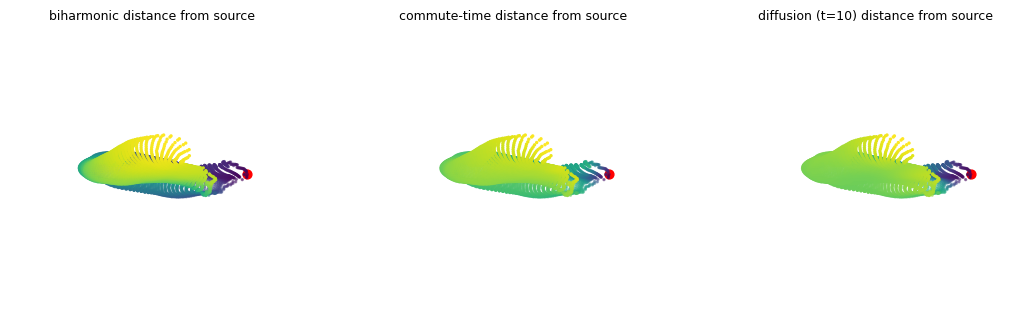

In [2]:
src = int(np.argmax(A.vertices[:, 0]))      # a vertex at one end (hippocampal head/tail)
idx = np.array([src])
d_bih = np.asarray(sb.biharmonic_distance(decA, indices=idx)).ravel()
d_com = np.asarray(sb.commute_time_distance(decA, indices=idx, warn_large=False)).ravel()
d_dif = np.asarray(sb.diffusion_distance(decA, t=10.0, indices=idx)).ravel()

V = A.vertices
fig = plt.figure(figsize=(11, 3.3))
for i, (d, ttl) in enumerate([(d_bih, "biharmonic"), (d_com, "commute-time"), (d_dif, "diffusion (t=10)")]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.scatter(V[:, 0], V[:, 1], V[:, 2], c=d, cmap="viridis", s=2)
    ax.scatter(*V[src], c="red", s=40)
    ax.set_title(f"{ttl} distance from source", fontsize=9); ax.set_axis_off(); ax.view_init(20, -70)
plt.tight_layout(); plt.show()

All three grow smoothly away from the red source along the hippocampal body —
they respect the intrinsic geometry. Because they are built from the spectrum,
they are **pose-invariant**: rotating the hippocampus leaves them unchanged.
Render the biharmonic field with the six-view tool for a publication-quality
view.

2026-06-09 02:09:08.638 (   0.261s) [    7F3F44963080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


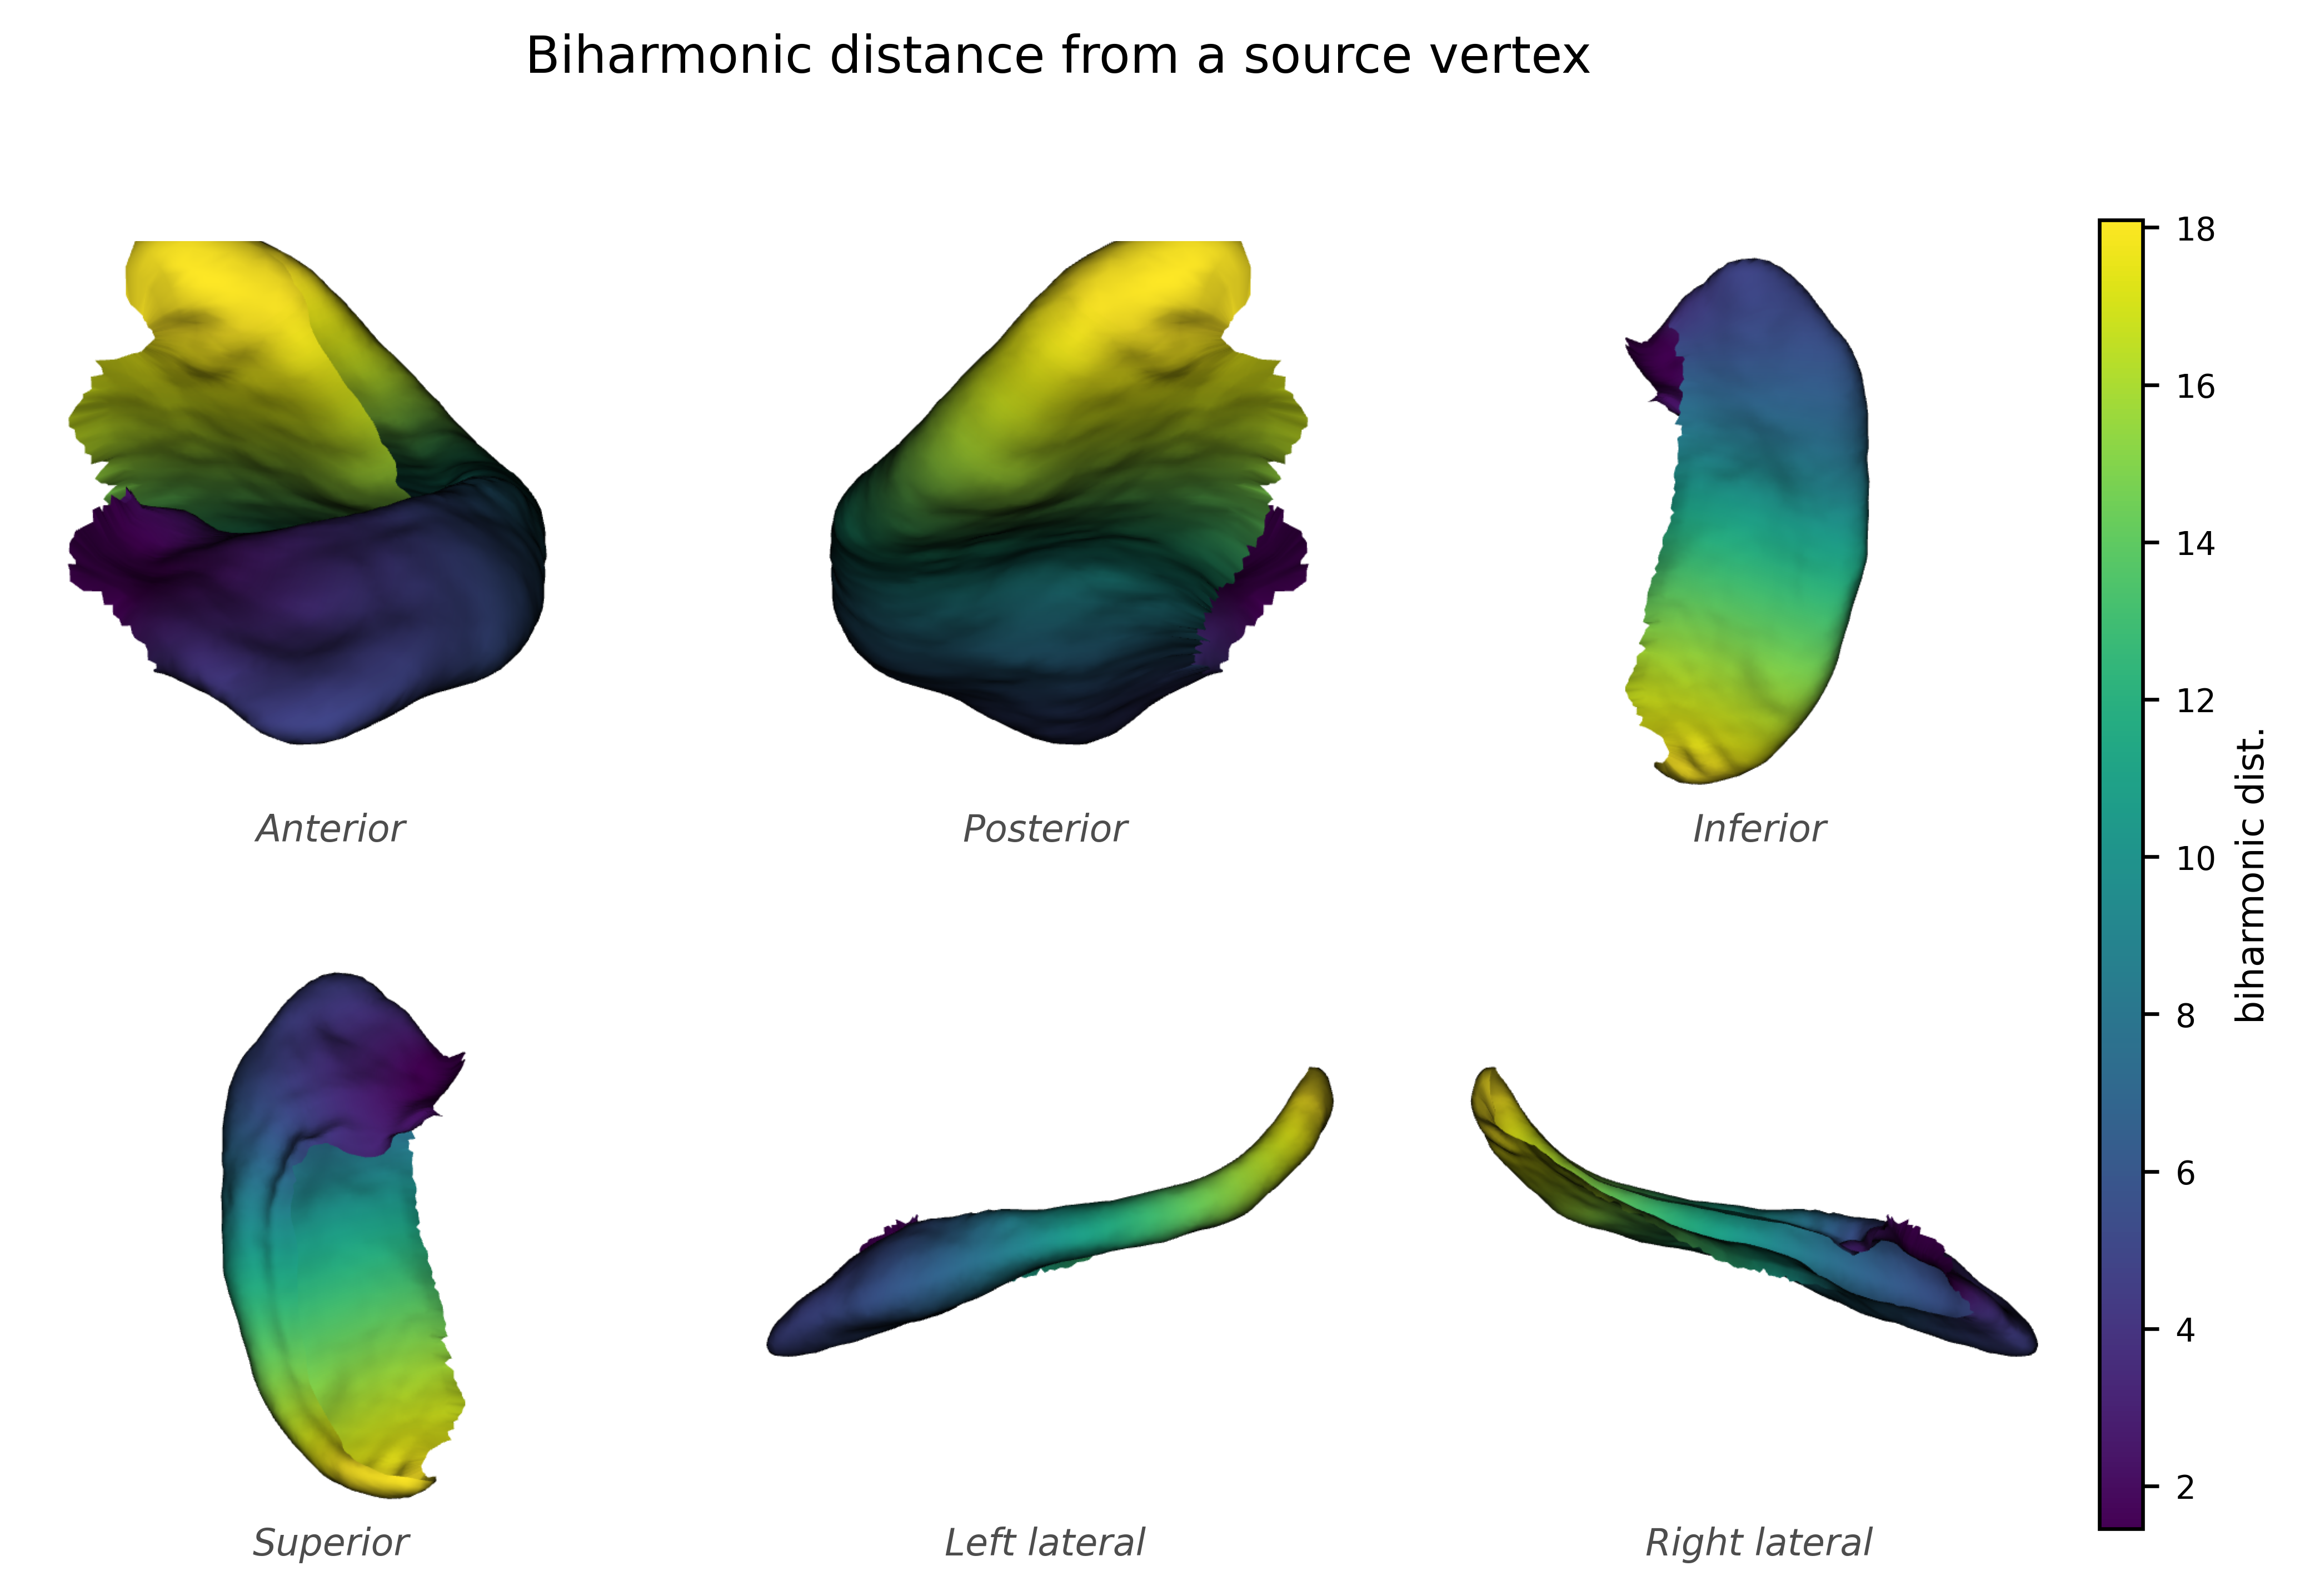

In [3]:
from spectralbrain.viz import plot_surface_sixview
fig = plot_surface_sixview(A, scalars=d_bih, cmap="viridis",
                           scalar_bar_title="biharmonic dist.",
                           title="Biharmonic distance from a source vertex")
plt.show()

## 3. Point-set distances: how far apart in space

Sometimes we want the opposite: how far two surfaces sit *as point sets in the
scanner*. **Chamfer** (average nearest-neighbour distance) and **Hausdorff**
(worst-case nearest-neighbour distance) answer this. Unlike everything spectral,
they are **extrinsic**: move one shape and the distance changes. We show this
directly by rotating a hippocampus and watching Chamfer rise, while its spectrum
(notebook 1) would not have budged.

In [4]:
PA, PB = A.vertices, B.vertices
print(f"sub03_L vs sub04_L  | Chamfer: {sb.chamfer_distance(PA, PB):.3f}  "
      f"Hausdorff: {sb.hausdorff_distance(PA, PB):.3f}")

# Rotate A by 30 degrees about z and recompute — extrinsic distances change.
th = np.deg2rad(30); Rz = np.array([[np.cos(th), -np.sin(th), 0],
                                    [np.sin(th), np.cos(th), 0], [0, 0, 1]])
PA_rot = PA @ Rz.T
print(f"sub03_L (rotated) vs sub04_L | Chamfer: {sb.chamfer_distance(PA_rot, PB):.3f}  "
      f"Hausdorff: {sb.hausdorff_distance(PA_rot, PB):.3f}")
print("\nExtrinsic distances move with pose; spectral descriptors and intrinsic "
      "distances do not. That invariance is the reason to work in the spectrum.")

sub03_L vs sub04_L  | Chamfer: 780.459  Hausdorff: 30.820
sub03_L (rotated) vs sub04_L | Chamfer: 1000.229  Hausdorff: 40.244

Extrinsic distances move with pose; spectral descriptors and intrinsic distances do not. That invariance is the reason to work in the spectrum.


## 4. Comparing descriptor distributions

A fourth notion of distance compares the *distributions* of a descriptor across
two shapes, ignoring point correspondence. `descriptor_distance` offers Wasserstein
(optimal transport), MMD, and simpler metrics. We compare the HKS distributions of
the two hippocampi.

In [5]:
for method in ["wasserstein", "euclidean", "cosine"]:
    d = sb.descriptor_distance(hksA.mean(0), hksB.mean(0), method=method)
    print(f"  HKS distribution distance ({method:11s}): {d:.4f}")

  HKS distribution distance (wasserstein): 0.0008
  HKS distribution distance (euclidean  ): 0.0008
  HKS distribution distance (cosine     ): 0.0000


## Exercises

1. **Isometry test.** Build the functional map from a hippocampus *to itself after
   a random rotation*. The map should be (almost) the identity. Is it?
2. **Weighting matters.** Overlay the biharmonic and commute-time fields from the
   same source along one axis of the hippocampus. Which is smoother, and why
   (think $1/\lambda_k$ vs $1/\lambda_k^2$)?
3. **Diffusion scale.** Recompute the diffusion distance for `t` in `[1, 10, 100]`.
   How does the field's spatial extent change with `t`?
4. **Symmetry of Hausdorff.** Compare `hausdorff_distance(A, B, symmetric=False)`
   in both directions. When are they different?
5. **Intrinsic vs extrinsic.** Rotate `sub03_L` and recompute (a) its ShapeDNA
   distance to `sub04_L` and (b) its Chamfer distance. Confirm only the extrinsic
   one changes.


## What's next

Single-structure analysis is behind us. **Notebook 08** scales up to a **cohort**:
loading groups with `load_group`, then vertex-wise statistics with proper
family-wise error control (max-statistic permutation, FDR, TFCE) and Cohen's d
maps. From here the series turns from geometry to inference.
